# Learning Eigenmodes using U-Nets

This time, we train Eigenmodes using U-Nets. The dataset preparation and all that is the same as FNOs

In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from LightPipes import *

import unet
from unet import UNet

import fno
from fno import overlap_loss, overlap_loss_int_phase


Load the dataset

In [2]:
NPZ_PATH = "datasets/dataset2.npz"   # ← path to the pre-converted .npz file

npz = np.load(NPZ_PATH)
data = {k: npz[k] for k in npz.files}

print(f"Loaded dataset from '{NPZ_PATH}'")
print(f"Keys    : {list(data.keys())}")
print(f"Samples : {data['gaussian_forward_real'].shape[0]}")
print(f"Grid    : {data['gaussian_forward_real'].shape[1:]} (H x W)")

Loaded dataset from 'datasets/dataset2.npz'
Keys    : ['eigenmode_1_real', 'eigenmode_2_real', 'eigenmode_3_real', 'eigenmode_4_real', 'eigenmode_1_imag', 'eigenmode_2_imag', 'eigenmode_3_imag', 'eigenmode_4_imag', 'gaussian_forward_real', 'gaussian_forward_imag', 'gaussian_reversed_real', 'gaussian_reversed_imag']
Samples : 10001
Grid    : (64, 64) (H x W)


Prepare the training dataset

In [3]:
N_EIGENMODES = 1

def normalize_11(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [-1, +1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return 2.0 * (arr - lo) / (hi - lo) - 1.0

def prepare_pairs(data, n_eigenmodes=N_EIGENMODES):
    """
    Build single-step predictor pairs from the dataset.

    For each consecutive pair of timesteps (t, t+1) and each eigenmode k we form:
      - Input  : [eigenmode_k_real_t,        eigenmode_k_imag_t,
                  gaussian_forward_real_t+1,  gaussian_forward_imag_t+1,
                  gaussian_reversed_real_t+1, gaussian_reversed_imag_t+1]  → (H, W, 6)
      - Target : [eigenmode_k_real_{t+1}, eigenmode_k_imag_{t+1}]          → (H, W, 2)

    Samples are interleaved by timestep (outer) then eigenmode (inner), matching
    prepare_pairs_slow, so that a simple train/test slice gives a proper temporal holdout:
      row index = t * n_eigenmodes + (k - 1)

    The Gaussian forward/reversed channels are normalised to [-1, +1].

    Returns
    -------
    X : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 6)
    Y : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 2)
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - 1
    total     = N_pairs * n_eigenmodes

    # Pre-allocate output arrays
    X = np.empty((total, H, W, 6), dtype=np.float32)
    Y = np.empty((total, H, W, 2), dtype=np.float32)

    # Load and normalise Gaussian arrays once — shared across all eigenmodes
    gfwd_real = normalize_11(data["gaussian_forward_real"][1:].astype(np.float32))  # (N-1, H, W)
    gfwd_imag = normalize_11(data["gaussian_forward_imag"][1:].astype(np.float32))
    grev_real = normalize_11(data["gaussian_reversed_real"][1:].astype(np.float32))
    grev_imag = normalize_11(data["gaussian_reversed_imag"][1:].astype(np.float32))

    # Load all eigenmode arrays up front
    em = {}
    for k in range(1, n_eigenmodes + 1):
        em[k] = (data[f"eigenmode_{k}_real"].astype(np.float32),
                 data[f"eigenmode_{k}_imag"].astype(np.float32))

    # Fill in timestep-major order: row = t * n_eigenmodes + (k-1)
    for t in range(N_pairs):
        for k in range(1, n_eigenmodes + 1):
            row = t * n_eigenmodes + (k - 1)
            em_real, em_imag = em[k]

            X[row, ..., 0] = em_real[t]       # eigenmode k at t
            X[row, ..., 1] = em_imag[t]
            X[row, ..., 2] = gfwd_real[t]     # Gaussian forward at t+1  (normalised)
            X[row, ..., 3] = gfwd_imag[t]
            X[row, ..., 4] = grev_real[t]     # Gaussian reversed at t+1 (normalised)
            X[row, ..., 5] = grev_imag[t]

            Y[row, ..., 0] = em_real[t + 1]   # eigenmode k at t+1
            Y[row, ..., 1] = em_imag[t + 1]

        if (t + 1) % 50 == 0 or (t + 1) == N_pairs:
            print(f"  Processed {t+1}/{N_pairs} timestep pairs ...")

    return torch.from_numpy(X), torch.from_numpy(Y)


X, Y = prepare_pairs(data)

print(f"Input  shape : {X.shape}")   # ((N-1)*4, H, W, 6)
print(f"Target shape : {Y.shape}")   # ((N-1)*4, H, W, 2)


  Processed 50/10000 timestep pairs ...
  Processed 100/10000 timestep pairs ...
  Processed 150/10000 timestep pairs ...
  Processed 200/10000 timestep pairs ...
  Processed 250/10000 timestep pairs ...
  Processed 300/10000 timestep pairs ...
  Processed 350/10000 timestep pairs ...
  Processed 400/10000 timestep pairs ...
  Processed 450/10000 timestep pairs ...
  Processed 500/10000 timestep pairs ...
  Processed 550/10000 timestep pairs ...
  Processed 600/10000 timestep pairs ...
  Processed 650/10000 timestep pairs ...
  Processed 700/10000 timestep pairs ...
  Processed 750/10000 timestep pairs ...
  Processed 800/10000 timestep pairs ...
  Processed 850/10000 timestep pairs ...
  Processed 900/10000 timestep pairs ...
  Processed 950/10000 timestep pairs ...
  Processed 1000/10000 timestep pairs ...
  Processed 1050/10000 timestep pairs ...
  Processed 1100/10000 timestep pairs ...
  Processed 1150/10000 timestep pairs ...
  Processed 1200/10000 timestep pairs ...
  Processed 

Prepare the dataset in a different way

In [ ]:

def normalize_11(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [-1, +1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return 2.0 * (arr - lo) / (hi - lo) - 1.0




def normalize_01(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [0, 1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)


def field_to_intensity_phase(real: np.ndarray, imag: np.ndarray):
    """
    Construct the full complex field from its real/imaginary components and
    return its intensity and phase.

    Parameters
    ----------
    real, imag : np.ndarray  — real and imaginary components of the field (any shape)

    Returns
    -------
    intensity : np.ndarray — |field|^2, same shape as input (not yet normalised)
    phase     : np.ndarray — angle(field) wrapped to [0, 2*pi), same shape as input
    """
    field = real + 1j * imag
    intensity = np.abs(field) ** 2
    phase = np.angle(field) % (2.0 * np.pi)   # wrap from (-pi, pi] to [0, 2*pi)
    return intensity, phase


def prepare_pairs_delta(data, n_eigenmodes=N_EIGENMODES, include_lag = False, lag=1):
    """
    Build single-step *delta* predictor pairs with extended probe context.

    Rather than using the raw real/imaginary components of each field, this
    version reconstructs the full complex field (real + i*imag) and derives
    its intensity (|field|^2) and phase (angle(field)) — these are used as
    the input/target channels instead.

    For each consecutive pair (t → t+1), with t starting from `lag` to allow
    access to t-lag, and each eigenmode k the input has 11 channels:

      ch  0,1  : norm(I_em_k(t)),   phi_em_k(t)           eigenmode intensity (normalised [0,1]) / phase ([0, 2*pi)) at t
      ch  2,3  : I→(t),  phi→(t)   = intensity (normalised [0,1]) / phase ([0, 2*pi)) of gaussian_forward[t]     current forward probe
      ch  4,5  : I←(t),  phi←(t)   = intensity (normalised [0,1]) / phase ([0, 2*pi)) of gaussian_reversed[t]    current reverse probe
      ch  6,7  : I→(t-N), phi→(t-N) = intensity/phase of gaussian_forward[t-lag]   lagged forward probe
      ch  8,9  : I←(t-N), phi←(t-N) = intensity/phase of gaussian_reversed[t-lag]  lagged reverse probe
      ch 10    : ΔI→(t,N) = I→(t) − I→(t-lag)               forward frame difference

    Target (2 channels):
      delta  [norm(I_em_k(t+1)) − norm(I_em_k(t)), phi_em_k(t+1) − phi_em_k(t)]
      (intensity delta uses the [0,1]-normalised intensity; phase delta uses the
      raw [0, 2*pi) phase — no normalisation applied to phase since it is
      already in a well-defined, bounded range)

    Parameters
    ----------
    lag : int
        Number of frames to look back for the lagged probe channels and frame
        difference (default 1, i.e. t-1).  The loop starts at t=lag so that
        t-lag is always a valid index, yielding (N_samples - lag - 1) pairs.

    Returns
    -------
    X : torch.Tensor  shape ((N-lag-1)*n_eigenmodes, H, W, 11)
    Y : torch.Tensor  shape ((N-lag-1)*n_eigenmodes, H, W,  2)  ← normalised residuals
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - lag - 1   # t runs from lag to N_samples-2 inclusive
    total     = N_pairs * n_eigenmodes

    if (include_lag):
        X = np.empty((total, H, W, 11), dtype=np.float32)
    else: 
        X = np.empty((total, H, W, 6), dtype=np.float32)

    Y = np.empty((total, H, W,  2), dtype=np.float32)

    # ── Load all Gaussian probe arrays (full time axis) and convert to intensity/phase ─
    gfwd_real = data["gaussian_forward_real"].astype(np.float32)    # (N, H, W)
    gfwd_imag = data["gaussian_forward_imag"].astype(np.float32)
    grev_real = data["gaussian_reversed_real"].astype(np.float32)
    grev_imag = data["gaussian_reversed_imag"].astype(np.float32)

    fwd_intensity_raw, fwd_phase = field_to_intensity_phase(gfwd_real, gfwd_imag)   # (N, H, W)
    rev_intensity_raw, rev_phase = field_to_intensity_phase(grev_real, grev_imag)   # (N, H, W)

    # Intensity → normalised to [0, 1]; phase is left as-is, already in [0, 2*pi)
    fwd_intensity, fwd_phase = normalize_01(fwd_intensity_raw)
    rev_intensity = normalize_01(rev_intensity_raw)

    # ── Eigenmode arrays: intensity normalised to [0,1], phase kept in [0, 2*pi) ─
    em_norm = {}
    for k in range(1, n_eigenmodes + 1):
        raw_r = data[f"eigenmode_{k}_real"].astype(np.float32)
        raw_i = data[f"eigenmode_{k}_imag"].astype(np.float32)
        intensity_k, phase_k = field_to_intensity_phase(raw_r, raw_i)
        em_norm[k] = (normalize_01(intensity_k), phase_k)

    # ── Fill arrays — t runs from lag to N_samples-2 ─────────────────────────
    for t in range(lag, N_samples - 1):
        pair_idx = t - lag   # 0-based row offset
        for k in range(1, n_eigenmodes + 1):
            row = pair_idx * n_eigenmodes + (k - 1)
            norm_i, norm_p = em_norm[k]

            # ch 0,1 — normalised eigenmode intensity/phase at t
            X[row, ..., 0] = norm_i[t]
            X[row, ..., 1] = norm_p[t]

            # ch 2,3 — current forward probe intensity/phase I→(t), phi→(t)
            X[row, ..., 2] = fwd_intensity[t]
            X[row, ..., 3] = fwd_phase[t]

            # ch 4,5 — current reverse probe intensity/phase I←(t), phi←(t)
            X[row, ..., 4] = rev_intensity[t]
            X[row, ..., 5] = rev_phase[t]

            if (include_lag): # Include previous Gaussian probes to get temporal data
                # ch 6,7 — lagged forward probe intensity/phase I→(t-N), phi→(t-N)
                X[row, ..., 6] = fwd_intensity[t - lag]
                X[row, ..., 7] = fwd_phase[t - lag]

                # ch 8,9 — lagged reverse probe intensity/phase I←(t-N), phi←(t-N)
                X[row, ..., 8] = rev_intensity[t - lag]
                X[row, ..., 9] = rev_phase[t - lag]

                # ch 10 — forward frame difference ΔI→(t,N) = I→(t) − I→(t-N)
                X[row, ..., 10] = fwd_intensity[t] - fwd_intensity[t - lag]

            # target — delta of intensity (normalised [0,1]) and phase (raw [0, 2*pi))
            Y[row, ..., 0] = norm_i[t + 1] - norm_i[t]
            Y[row, ..., 1] = norm_p[t + 1] - norm_p[t]

        if t % 50 == 0 or t == N_samples - 2:
            print(f"  Processed {t - lag + 1}/{N_pairs} timestep pairs ...")

    return torch.from_numpy(X), torch.from_numpy(Y)


def reconstruct_from_delta(
    input_sample: torch.Tensor,
    delta_pred: torch.Tensor,
) -> torch.Tensor:
    """
    Reconstruct the predicted next eigenmode (intensity, phase) from the
    input and a predicted delta.

    Parameters
    ----------
    input_sample : torch.Tensor  (..., 2)  — eigenmode [intensity, phase] at t
    delta_pred   : torch.Tensor  (..., 2)  — predicted [Δintensity, Δphase]

    Returns
    -------
    torch.Tensor  (..., 2)  — predicted eigenmode [intensity, phase] at t+1
    """
    return input_sample + delta_pred

# ── Example usage ──────────────────────────────────────────────────────────────

LAG = 2  # ← set the desired lag N here
X, Y = prepare_pairs_delta(data, lag=LAG)

print(f"Lag            : {LAG} frames")
print(f"Delta input  shape : {X.shape}")   # ((N-lag-1)*n_eigenmodes, H, W, 11)
print(f"Delta target shape : {Y.shape}  ← residuals [Δintensity (norm. [0,1]), Δphase (raw [0, 2*pi))]")


  Processed 49/9998 timestep pairs ...
  Processed 99/9998 timestep pairs ...
  Processed 149/9998 timestep pairs ...
  Processed 199/9998 timestep pairs ...
  Processed 249/9998 timestep pairs ...
  Processed 299/9998 timestep pairs ...
  Processed 349/9998 timestep pairs ...
  Processed 399/9998 timestep pairs ...
  Processed 449/9998 timestep pairs ...
  Processed 499/9998 timestep pairs ...
  Processed 549/9998 timestep pairs ...
  Processed 599/9998 timestep pairs ...
  Processed 649/9998 timestep pairs ...
  Processed 699/9998 timestep pairs ...
  Processed 749/9998 timestep pairs ...
  Processed 799/9998 timestep pairs ...
  Processed 849/9998 timestep pairs ...
  Processed 899/9998 timestep pairs ...
  Processed 949/9998 timestep pairs ...
  Processed 999/9998 timestep pairs ...
  Processed 1049/9998 timestep pairs ...
  Processed 1099/9998 timestep pairs ...
  Processed 1149/9998 timestep pairs ...
  Processed 1199/9998 timestep pairs ...
  Processed 1249/9998 timestep pairs .

Sanity-check: verify intensity/phase modelling for a single sample

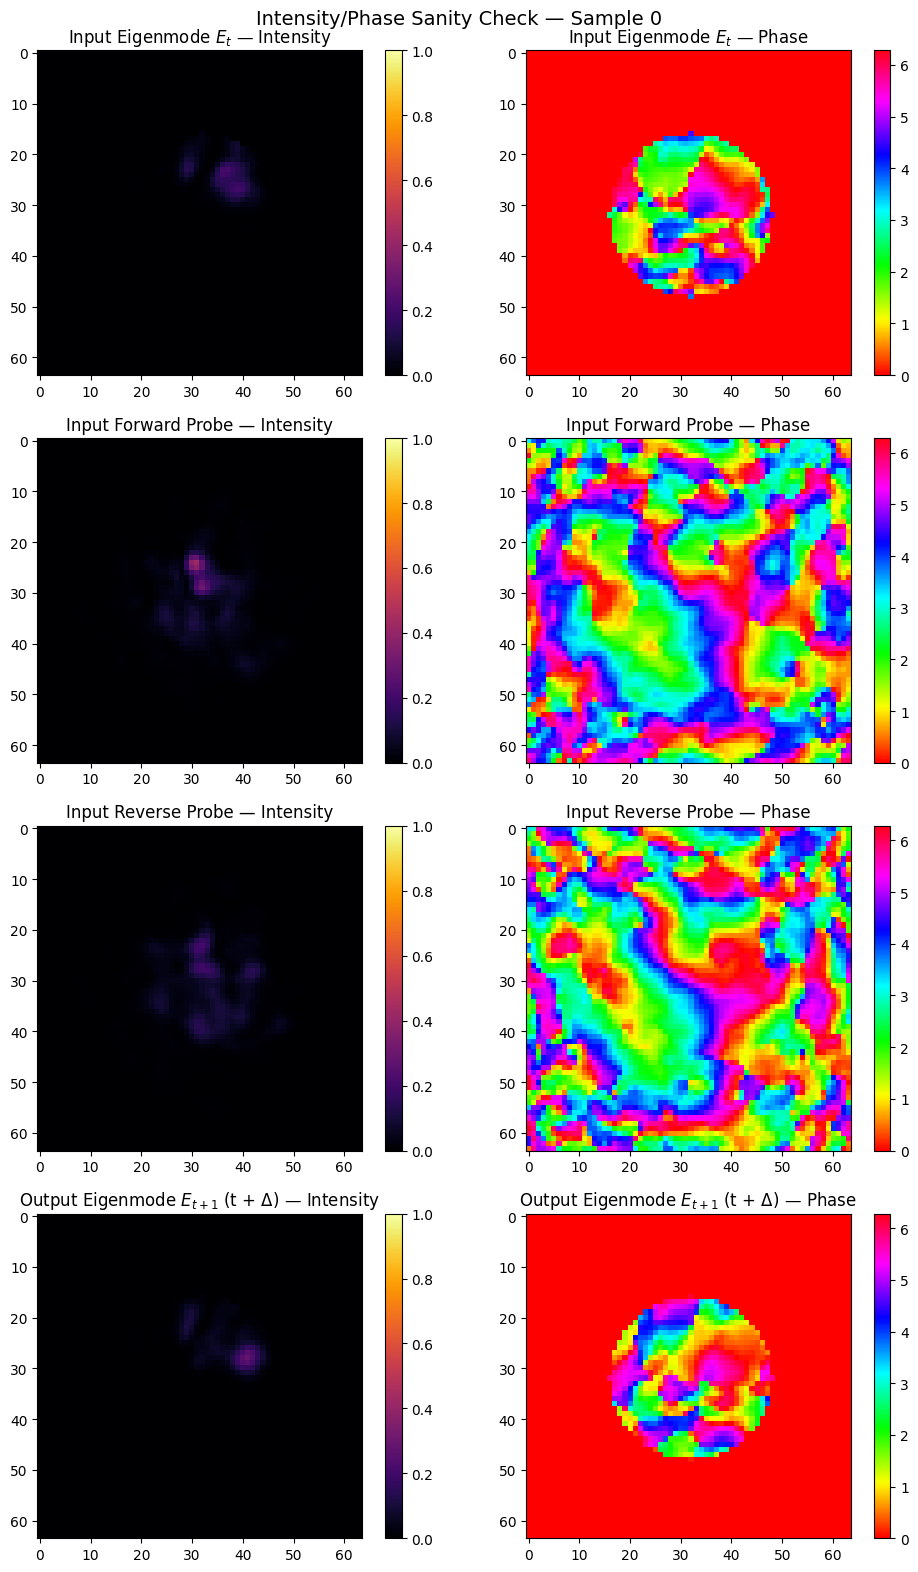

Eigenmode intensity range at t   : [0.0000, 0.2125]  (expected within [0, 1])
Eigenmode phase range at t       : [0.0000, 6.2747]  (expected within [0, 2*pi))
Eigenmode intensity range at t+1 : [0.0000, 0.2825]
Eigenmode phase range at t+1     : [0.0000, 6.2783]


In [5]:
check_index = 0   # ← row of X / Y to inspect

check_input  = X[check_index].numpy()   # (H, W, 6 or 11)
check_target = Y[check_index].numpy()   # (H, W, 2)  — [Δintensity, Δphase]

# Input channels (see prepare_pairs_delta docstring):
#   0,1 — eigenmode intensity (normalised [0,1]) / phase ([0, 2*pi)) at t
#   2,3 — forward probe intensity / phase at t
#   4,5 — reverse probe intensity / phase at t
in_em_intensity  = check_input[..., 0]
in_em_phase      = check_input[..., 1]
in_fwd_intensity = check_input[..., 2]
in_fwd_phase     = check_input[..., 3]
in_rev_intensity = check_input[..., 4]
in_rev_phase     = check_input[..., 5]

# Reconstruct the "output" eigenmode at t+1 = (t) + delta
out_em_intensity = in_em_intensity + check_target[..., 0]
out_em_phase     = in_em_phase + check_target[..., 1]

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Intensity/Phase Sanity Check — Sample {check_index}", fontsize=14)

rows = [
    ((in_em_intensity,  in_em_phase),  "Input Eigenmode $E_t$"),
    ((in_fwd_intensity, in_fwd_phase), "Input Forward Probe"),
    ((in_rev_intensity, in_rev_phase), "Input Reverse Probe"),
    ((out_em_intensity, out_em_phase), "Output Eigenmode $E_{t+1}$ (t + Δ)"),
]

for i, ((intensity, phase), title) in enumerate(rows):
    im_int = axes[i, 0].imshow(intensity, cmap='inferno', vmin=0, vmax=1)
    axes[i, 0].set_title(f"{title} — Intensity")
    plt.colorbar(im_int, ax=axes[i, 0])

    im_ph = axes[i, 1].imshow(phase, cmap='hsv', vmin=0, vmax=2 * np.pi)
    axes[i, 1].set_title(f"{title} — Phase")
    plt.colorbar(im_ph, ax=axes[i, 1])

plt.tight_layout()
plt.show()

print(f"Eigenmode intensity range at t   : [{in_em_intensity.min():.4f}, {in_em_intensity.max():.4f}]  (expected within [0, 1])")
print(f"Eigenmode phase range at t       : [{in_em_phase.min():.4f}, {in_em_phase.max():.4f}]  (expected within [0, 2*pi))")
print(f"Eigenmode intensity range at t+1 : [{out_em_intensity.min():.4f}, {out_em_intensity.max():.4f}]")
print(f"Eigenmode phase range at t+1     : [{out_em_phase.min():.4f}, {out_em_phase.max():.4f}]")


Build train/test pairs

In [6]:
n_total = int(0.50*X.shape[0])
n_train = int(0.85*n_total)
batch_size = 10

x_train =  X[:n_train]
x_test =  X[n_train:n_total]

y_train = Y[:n_train]
y_test = Y[n_train:n_total]

N = x_train.shape[2]

training_set = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)

Instantiate the U-Net Architecture

In [7]:
epochs = 50

# These control the step-wise updates on the LR

learn_rate = 0.001  # initial LR
decay_rate = 0.001  # initial weight decay
step_size  = 12     # epochs between LR decay steps
gamma      = 0.5    # LR decay factor

# U-Net architecture

nnType = 0
kernelSize = 3
layers = 1
dropRate = 0.1

# Physical parameters 
size = 0.45
lensSize = 0.1125

Load up the GPU (if not already done so)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


Apply aperture to output channel 

In [9]:
def torch_circ_aperture(field_batch: torch.Tensor, size: float, lensSize: float) -> torch.Tensor:
    """
    Applies a circular aperture to a batch of complex fields represented
    as real/imaginary channels.

    Parameters
    ----------
    field_batch : torch.Tensor  shape (batch, H, W, C)
                  where C=2 holds [real, imag] channels
    size        : float — physical side length of the window (metres)
    lensSize    : float — aperture radius (metres)

    Returns
    -------
    torch.Tensor — same shape as field_batch, zeroed outside the aperture
    """
    _, H, W, _ = field_batch.shape
    device = field_batch.device

    # Build physical coordinate axes centred at zero — same convention as LightPipes
    x = torch.linspace(-size / 2, size / 2, W, device=device)
    y = torch.linspace(-size / 2, size / 2, H, device=device)
    yy, xx = torch.meshgrid(y, x, indexing="ij")   # (H, W)

    # Binary mask: 1 inside aperture, 0 outside
    mask = (xx**2 + yy**2 <= lensSize**2).float()  # (H, W)
    mask = mask.unsqueeze(0).unsqueeze(-1)          # (1, H, W, 1) — broadcasts over batch and channels

    return field_batch * mask


Instantiate and train the UNet. Use the fidelity as a loss metric

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

u_net = UNet(64, nnType, layers=layers).to(device)
optim = Adam(u_net.parameters(), lr=learn_rate, weight_decay=decay_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=step_size, gamma=gamma)

loss = overlap_loss_int_phase
freq_print = 1

n_train_batches = len(training_set)
n_test_batches = len(testing_set)

train_mse_history = []
test_rel_l2_history = []

for epoch in range(epochs):

    # Evaluate the training metric
    u_net.train()
    train_mse = 0.0

    for step, (input_batch, delta_batch) in enumerate(training_set):
        input_batch = input_batch.to(device)   # (B, H, W, 6)
        delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

        optim.zero_grad()

        # UNet (PyTorch conv layers) expects channels-first (B, C, H, W)
        input_batch_cf = input_batch.permute(0, 3, 1, 2)   # (B, 6, H, W)

        # Predict ΔE and apply aperture — permute network output back to channels-last
        delta_pred_batch = torch_circ_aperture(
            u_net(input_batch_cf).permute(0, 2, 3, 1), size=size, lensSize=lensSize
        )  # (B, H, W, 2)

        # Reconstruct E_{t+1} = E_t + ΔE  (channels 0,1 of input are the eigenmode at t)
        output_pred_batch = reconstruct_from_delta(input_batch[..., :2], delta_pred_batch)   # (B, H, W, 2)
        output_batch      = reconstruct_from_delta(input_batch[..., :2], delta_batch)        # (B, H, W, 2)

        loss_f = loss(output_pred_batch, output_batch)
        loss_f.backward()
        optim.step()
        train_mse += loss_f.item()

    train_mse /= n_train_batches
    print("Training batches computed")

    scheduler.step()

    with torch.no_grad():
        u_net.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, delta_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)   # (B, H, W, 6)
            delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

            input_batch_cf = input_batch.permute(0, 3, 1, 2)   # (B, 6, H, W)

            # Predict ΔE and apply aperture
            delta_pred_batch = torch_circ_aperture(
                u_net(input_batch_cf).permute(0, 2, 3, 1), size=size, lensSize=lensSize
            )  # (B, H, W, 2)

            # Reconstruct E_{t+1} = E_t + ΔE
            output_pred_batch = reconstruct_from_delta(input_batch[..., :2], delta_pred_batch)   # (B, H, W, 2)
            output_batch      = reconstruct_from_delta(input_batch[..., :2], delta_batch)        # (B, H, W, 2)
            loss_f = loss(output_pred_batch, output_batch)

            test_relative_l2 += loss_f.item()

        test_relative_l2 /= n_test_batches

    train_mse_history.append(train_mse)
    test_rel_l2_history.append(test_relative_l2)

    if epoch % freq_print == 0:
        print(f"========= Epoch {epoch+1}/{epochs} Summary ========= Train Loss: {train_mse:.6f} | Mean Test Loss: {test_relative_l2:.4f}\n")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
Training batches computed
Training batches computed
========= Epoch 1/50 Summary ========= Train Loss: 0.483482 | Mean Test Loss: 0.4830

========= Epoch 1/50 Summary ========= Train Loss: 0.483482 | Mean Test Loss: 0.4830

Training batches computed
Training batches computed
========= Epoch 2/50 Summary ========= Train Loss: 0.480524 | Mean Test Loss: 0.4830

========= Epoch 2/50 Summary ========= Train Loss: 0.480524 | Mean Test Loss: 0.4830

Training batches computed
Training batches computed
========= Epoch 3/50 Summary ========= Train Loss: 0.480477 | Mean Test Loss: 0.4829

========= Epoch 3/50 Summary ========= Train Loss: 0.480477 | Mean Test Loss: 0.4829

Training batches computed
Training batches computed
========= Epoch 4/50 Summary ========= Train Loss: 0.480694 | Mean Test Loss: 0.4830

========= Epoch 4/50 Summary ========= Train Loss: 0.480694 | Mean Test Loss: 0.4830

Training batches computed
Training batches compu

KeyboardInterrupt: 

Make a plot of the resulting loss curve

Plot saved to training_plots/training_curves.png


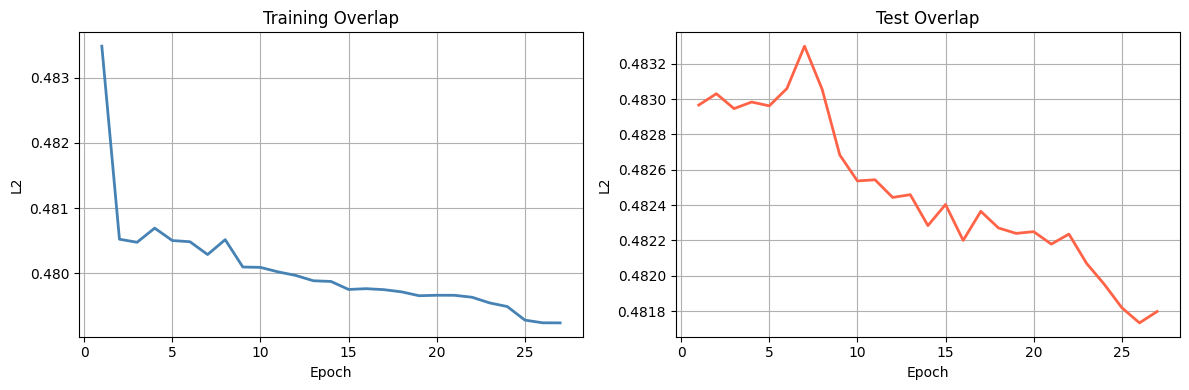

In [13]:
import os

epochs=epochs
epochs=27
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_mse_history, color='steelblue', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L2")
axes[0].set_title("Training Overlap")
axes[0].grid(True)

axes[1].plot(epochs_range, test_rel_l2_history, color='tomato', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("L2")
axes[1].set_title("Test Overlap")
axes[1].grid(True)

plt.tight_layout()

plots_dir = "training_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/training_curves.png")

plt.show()

Save the model

In [14]:
models_dir = "trained_models_eigen_unet"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "fno_eigen.pth")

torch.save({
    "model_state_dict": u_net.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "epochs": epochs,
    "train_mse_history": train_mse_history,
    "test_rel_l2_history": test_rel_l2_history,
}, model_path)

print(f"Model saved to {model_path}")

Model saved to trained_models_eigen_unet\fno_eigen.pth


# Inference

In [15]:
# Assign device (if applicable)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Load the model checkpoint (if applicable)

checkpoint = torch.load("trained_models_eigen_unet/fno_eigen.pth")
u_net = UNet(64, nnType, layers=layers).to(device)
u_net.load_state_dict(checkpoint["model_state_dict"])


Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


<All keys matched successfully>

plot

In [16]:
sample_index = 20
size = 0.45
lensSize = size / 4

# --- Run inference ---
input_sample = x_test[sample_index].unsqueeze(0).to(device)   # (1, H, W, 6 or 11)
input_sample_cf = input_sample.permute(0, 3, 1, 2)             # (1, C, H, W) — channels-first for UNet

u_net.eval()
with torch.no_grad():
    # UNet predicts the normalised [Δintensity, Δphase]; apply aperture (permute back to channels-last)
    delta_pred = torch_circ_aperture(
        u_net(input_sample_cf).permute(0, 2, 3, 1), size=size, lensSize=lensSize
    )  # (1, H, W, 2)

# --- Extract eigenmode intensity/phase at t from input (channels 0, 1) ---
input_np           = x_test[sample_index].cpu().numpy()          # (H, W, 6 or 11)
eigenmode_in_i      = input_np[..., 0]                            # normalised intensity at t
eigenmode_in_p      = input_np[..., 1]                            # normalised phase at t
fwd_intensity_in    = input_np[..., 2]                            # forward probe intensity at t
fwd_phase_in        = input_np[..., 3]                            # forward probe phase at t

# --- Reconstruct true (intensity, phase) at t+1 = (t) + Δtrue ---
delta_true_np   = y_test[sample_index].cpu().numpy()          # (H, W, 2) — true [Δintensity, Δphase]
eigenmode_true_i = eigenmode_in_i + delta_true_np[..., 0]
eigenmode_true_p = eigenmode_in_p + delta_true_np[..., 1]

# --- Reconstruct predicted (intensity, phase) at t+1 = (t) + Δpred ---
delta_pred_np    = delta_pred.squeeze(0).cpu().numpy()         # (H, W, 2) — predicted [Δintensity, Δphase]
eigenmode_pred_i = eigenmode_in_i + delta_pred_np[..., 0]
eigenmode_pred_p = eigenmode_in_p + delta_pred_np[..., 1]

print(f"Input eigenmode intensity range  : [{eigenmode_in_i.min():.4f}, {eigenmode_in_i.max():.4f}]")
print(f"True output intensity range      : [{eigenmode_true_i.min():.4f}, {eigenmode_true_i.max():.4f}]")
print(f"Predicted output intensity range : [{eigenmode_pred_i.min():.4f}, {eigenmode_pred_i.max():.4f}]")


Input eigenmode intensity range  : [0.0000, 0.4020]
True output intensity range      : [0.0000, 0.4130]
Predicted output intensity range : [0.0000, 0.4021]


Plot saved to inference_plots/inference_sample20.png


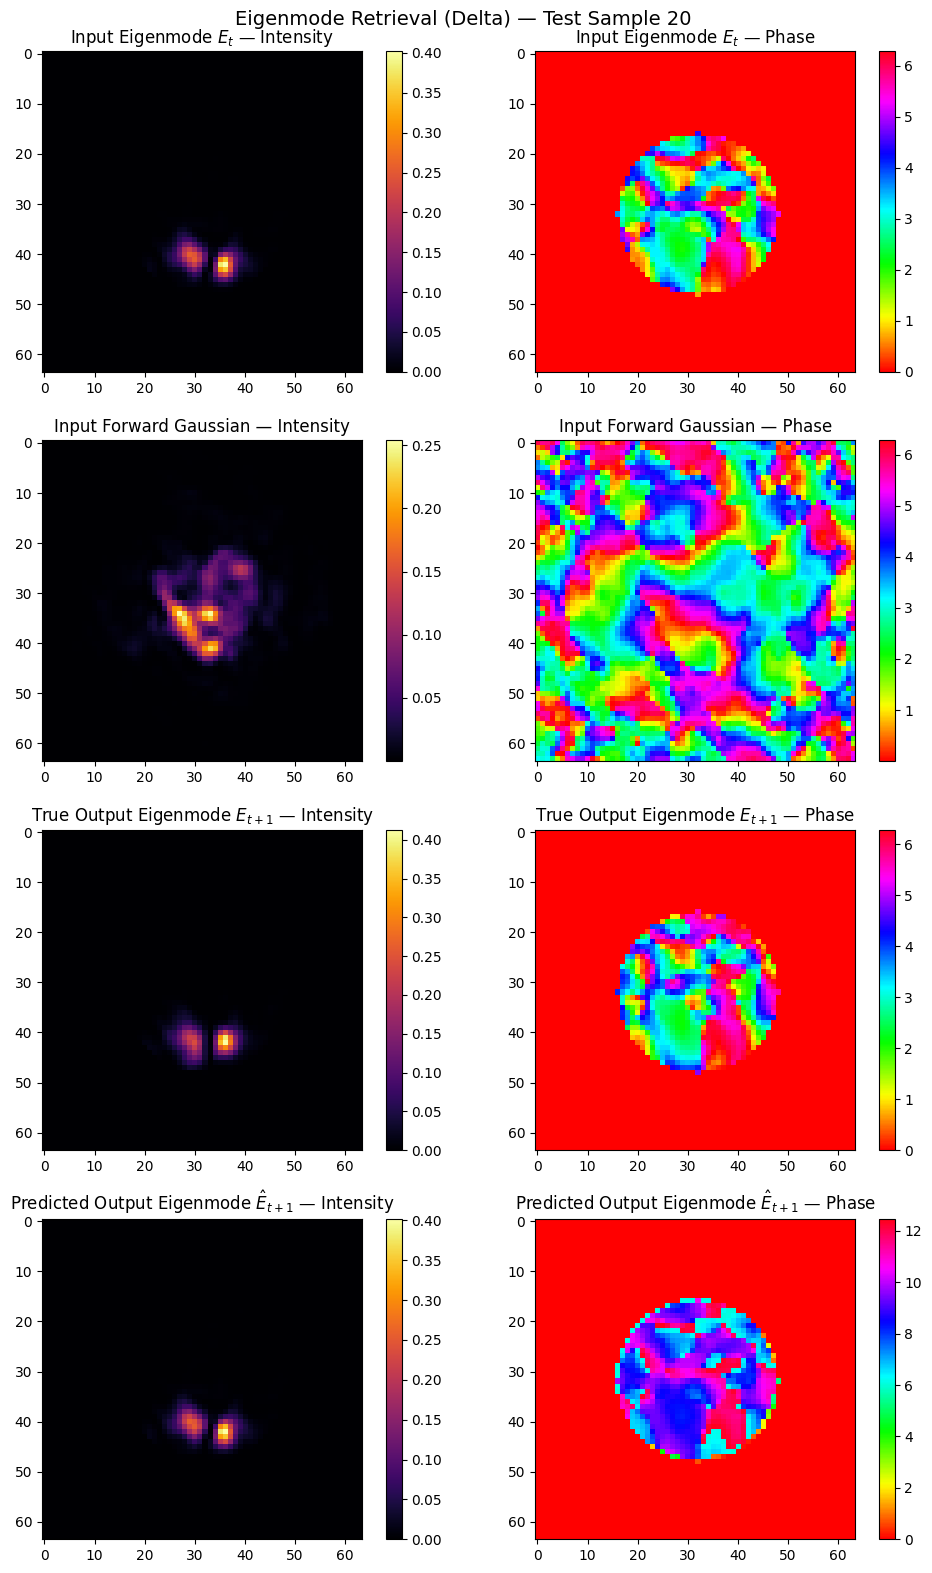

In [17]:
# --- Plot reconstructed fields ---
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Eigenmode Retrieval (Delta) — Test Sample {sample_index}", fontsize=14)

rows = [
    ((eigenmode_in_i,   eigenmode_in_p),   "Input Eigenmode $E_t$"),
    ((fwd_intensity_in, fwd_phase_in),     "Input Forward Gaussian"),
    ((eigenmode_true_i, eigenmode_true_p), "True Output Eigenmode $E_{t+1}$"),
    ((eigenmode_pred_i, eigenmode_pred_p), "Predicted Output Eigenmode $\\hat{E}_{t+1}$"),
]

for i, ((intensity, phase), title) in enumerate(rows):
    im_int = axes[i, 0].imshow(intensity, cmap='inferno')
    axes[i, 0].set_title(f"{title} — Intensity")
    plt.colorbar(im_int, ax=axes[i, 0])

    im_ph = axes[i, 1].imshow(phase, cmap='hsv')
    axes[i, 1].set_title(f"{title} — Phase")
    plt.colorbar(im_ph, ax=axes[i, 1])

plt.tight_layout()

plots_dir = "inference_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, f"inference_sample{sample_index}.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/inference_sample{sample_index}.png")

plt.show()


How much of our predictions still reflect the inputs? 

In [25]:
# --- Identity baseline and model fidelity over the full test set ---
# Note: testing_set yields (input, delta), so the eigenmode at t+1 must be
# reconstructed as (t) + delta before computing the overlap fidelity.
#
# Since our channels are now [intensity, phase] rather than [real, imag], we
# rebuild the equivalent complex field as  field = sqrt(intensity) * exp(i*phase)
# (intensity = |field|^2, phase = angle(field)), then compute the usual overlap
# fidelity on that reconstructed field. Intensities can go slightly negative
# after adding deltas because of prediction/normalisation noise, so they are
# clamped to zero before the sqrt.

identity_fidelities_test = []
identity_fidelities_pred = []

u_net.eval()
with torch.no_grad():
    for input_batch, delta_batch in testing_set:
        input_batch = input_batch.to(device)   # (B, H, W, 6 or 11)
        delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true [Δintensity, Δphase]

        em_t = input_batch[..., :2]  # eigenmode [intensity, phase] at t, (B, H, W, 2)

        # Reconstruct ground-truth (intensity, phase) at t+1 = (t) + delta_true
        output_batch  = reconstruct_from_delta(em_t, delta_batch)          # (B, H, W, 2)
        B_intensity    = output_batch[..., 0].clamp(min=0.0)
        B_phase        = output_batch[..., 1]
        B_field        = torch.sqrt(B_intensity) * torch.exp(1j * B_phase)     # (B, H, W)
        norm_B_sq      = (B_field.abs() ** 2).sum(dim=(-2, -1))                 # (B,)

        # ── Identity baseline: field at t  vs  field at t+1 ──────────────────
        A_intensity = em_t[..., 0].clamp(min=0.0)
        A_phase     = em_t[..., 1]
        A           = torch.sqrt(A_intensity) * torch.exp(1j * A_phase)         # (B, H, W)
        inner_id    = (A.conj() * B_field).sum(dim=(-2, -1))
        norm_A_sq   = (A.abs() ** 2).sum(dim=(-2, -1))
        F_id        = inner_id.abs() ** 2 / (norm_A_sq * norm_B_sq + 1e-8)      # (B,)
        identity_fidelities_test.extend(F_id.cpu().tolist())

        # ── Model: reconstruct predicted (intensity, phase) at t+1 ───────────
        input_batch_cf   = input_batch.permute(0, 3, 1, 2)   # (B, C, H, W) — channels-first for UNet
        delta_pred_batch = torch_circ_aperture(
            u_net(input_batch_cf).permute(0, 2, 3, 1), size=size, lensSize=lensSize
        )  # (B, H, W, 2)
        output_pred_batch = reconstruct_from_delta(em_t, delta_pred_batch)  # (B, H, W, 2)
        C_intensity  = output_pred_batch[..., 0].clamp(min=0.0)
        C_phase      = output_pred_batch[..., 1]
        C            = torch.sqrt(C_intensity) * torch.exp(1j * C_phase)        # (B, H, W)
        inner_pred   = (C.conj() * B_field).sum(dim=(-2, -1))
        norm_C_sq    = (C.abs() ** 2).sum(dim=(-2, -1))
        F_pred       = inner_pred.abs() ** 2 / (norm_C_sq * norm_B_sq + 1e-8)    # (B,)
        identity_fidelities_pred.extend(F_pred.cpu().tolist())

identity_fidelities_test = np.array(identity_fidelities_test)
identity_fidelities_pred = np.array(identity_fidelities_pred)

print(f"Samples evaluated          : {len(identity_fidelities_test)}")
print(f"Identity baseline  — mean F : {identity_fidelities_test.mean():.4f}  |  std: {identity_fidelities_test.std():.4f}")
print(f"Model predictions  — mean F : {identity_fidelities_pred.mean():.4f}  |  std: {identity_fidelities_pred.std():.4f}")


Samples evaluated          : 750
Identity baseline  — mean F : 0.0464  |  std: 0.1664
Model predictions  — mean F : 0.0476  |  std: 0.1680
